# N-HiTS Forecasting

## Imports

In [2]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from darts import TimeSeries
from darts.models import NHiTSModel
from darts.metrics import smape, mase, rmse, mae

from pytorch_lightning.callbacks import EarlyStopping

import torch
torch.set_default_dtype(torch.float32)



## Load Dataset

In [3]:
df = pd.read_csv("oil_price.csv")

df.columns = ["ds", "y"]
df["ds"] = pd.to_datetime(df["ds"])


## Data Cleaning & Missing Values

In [4]:
df = df.drop_duplicates().sort_values("ds").reset_index(drop=True)

df["y"] = pd.to_numeric(df["y"], errors="coerce")
df = df.fillna(method="ffill").fillna(method="bfill")


## Train / Validation / Test Split (70/10/20)

In [5]:
train_size = int(len(df)*0.7)
val_size   = int(len(df)*0.1)

train_df = df[:train_size]
val_df   = df[train_size:train_size+val_size]
test_df  = df[train_size+val_size:]


## Convert to TimeSeries

In [6]:
series = TimeSeries.from_dataframe(
    df,
    time_col="ds",
    value_cols="y",
    fill_missing_dates=True,
    freq="B"
)

train_series = series[:train_size]
val_series   = series[train_size:train_size+val_size]
test_series  = series[train_size+val_size:]


## Model (N-HiTS)

In [7]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=30,
    mode="min"
)

model_nhits = NHiTSModel(
    input_chunk_length=60,
    output_chunk_length=7,
    n_epochs=200,
    batch_size=32,
    random_state=42,
    dropout=0.1,
    pl_trainer_kwargs={
        "callbacks": [early_stop],
        "accelerator": "cpu"
    }
)


## Training

In [8]:
model_nhits.fit(
    train_series,
    val_series=val_series
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name            | Type             | Params | Mode 
-------------------------------------------------------------
0 | criterion       | MSELoss          | 0      | train
1 | train_criterion | MSELoss          | 0      | train
2 | val_criterion   | MSELoss          | 0      | train
3 | train_metrics   | MetricCollection | 0      | train
4 | val_metrics     | MetricCollection | 0      | train
5 | stacks          | ModuleList       | 907 K  | train
-------------------------------------------------------------
876 K     Trainable params
30.8 K    Non-trainable params
907 K     Total params
3.630     Total estimated model params size (MB)
42        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

NHiTSModel(output_chunk_shift=0, num_stacks=3, num_blocks=1, num_layers=2, layer_widths=512, pooling_kernel_sizes=None, n_freq_downsample=None, dropout=0.1, activation=ReLU, MaxPool1d=True, input_chunk_length=60, output_chunk_length=7, n_epochs=200, batch_size=32, random_state=42, pl_trainer_kwargs={'callbacks': [<pytorch_lightning.callbacks.early_stopping.EarlyStopping object at 0x14ee7d490>], 'accelerator': 'cpu'})

## Forecast

In [9]:
forecast_nhits = model_nhits.historical_forecasts(
    series,
    start=len(train_series)+len(val_series),
    forecast_horizon=7,
    retrain=False
)


GPU available: True (mps), used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Evaluation

In [10]:
insample = series.slice(series.start_time(), forecast_nhits.start_time() - series.freq)
test_aligned = test_series.slice_intersect(forecast_nhits)

print("N-HiTS Performance")
print("sMAPE:", smape(test_aligned, forecast_nhits))
print("RMSE:", rmse(test_aligned, forecast_nhits))
print("MAE:", mae(test_aligned, forecast_nhits))
print("MASE:", mase(test_aligned, forecast_nhits, insample, 7))


N-HiTS Performance
sMAPE: 5.991696069960679
RMSE: 5.12928177179444
MAE: 3.5833908498642457
MASE: 1.9462239834977533


## Plot

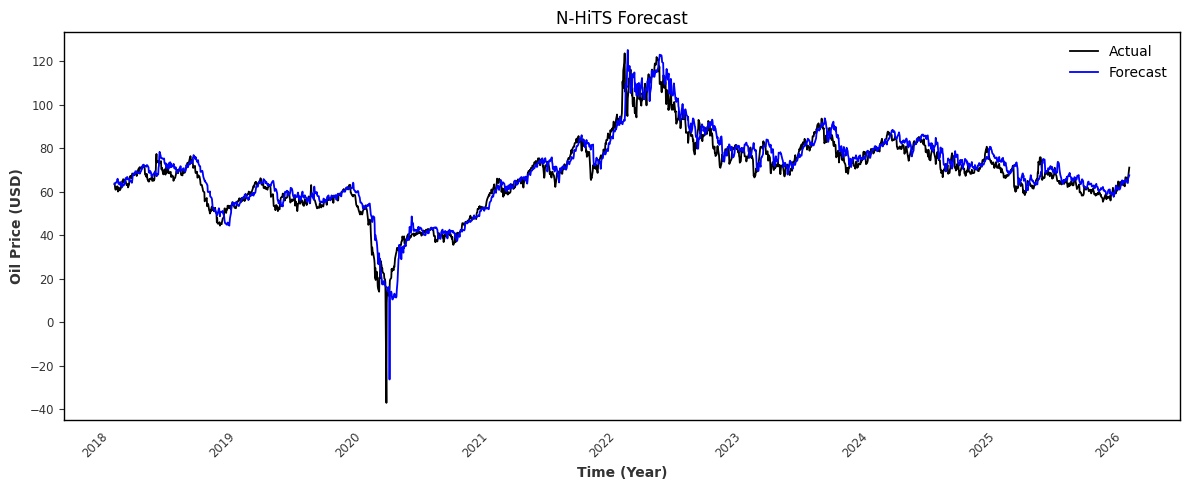

In [32]:
plt.figure(figsize=(12,5))

# ambil time index
time_index = test_series.time_index

# ambil nilai
actual = test_series.values().flatten()
pred = forecast_nhits.values().flatten()

# samakan panjang
min_len = min(len(time_index), len(actual), len(pred))
time_index = time_index[-min_len:]
actual = actual[-min_len:]
pred = pred[-min_len:]

# plot
plt.plot(time_index, actual, label="Actual", color="black")
plt.plot(time_index, pred, label="Forecast", color="blue")

# MATIKAN GRID (ini yang bikin kotak-kotak hilang)
plt.grid(False)

# AKTIFKAN BORDER (spines)
ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

plt.legend()
plt.title("N-HiTS Forecast")
plt.xlabel("Time (Year)")
plt.ylabel("Oil Price (USD)")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [27]:
pred_nhits = forecast_nhits.values().flatten()
# np.save("pred_nhits.npy", forecast_nhits.values().flatten())
print(len(pred_nhits))

2091
